# Laptop Hardware & Pricing Analysis with Linear Regression

## Project Goal

The goal of this project is to determine whether laptop hardware specifications can help predict laptop price.

This notebook uses the cleaned modeling dataset created in the data acquisition and cleaning notebook.

## Slice 1 Baseline Laptop Price Model

The first model will examine whether a small group of common laptop specifications can help explain differences in laptop price.

### Features

- RAM capacity (`ram_gb`)
- Storage capacity (`storage_gb`)
- Screen size (`screen_size_candidate`)
- CPU brand (`cpu_brand`)
- GPU brand (`gpu_brand`)

### Target

- Laptop price (`price`)

CPU and GPU brand are intentionally simplified features in this first model. They identify broad hardware vendors but do not capture differences between individual processor or graphics card models.

More detailed CPU and GPU analysis will be handled separately in later stages of the project.

In [1]:
import pandas as pd

In [2]:
model_df = pd.read_csv(
    "data/plugpcs_laptops_model_2026-09-29.csv"
)
print(model_df.shape)
display(model_df.head())

(1477, 22)


,name,brand,price,currency,ram_gb,storage_gb,storage_status,cpu,gpu,gpu_brand,...,availability_status,description,source_url,Unnamed: 15,Unnamed: 16,category,sku,ram_status,availability,seller_url
0,"18"" Avon Best",Digital Storm,3837.0,USD,16,2048,specified,Intel Core Ultra 9 290HX,NVIDIA RTX 5080,NVIDIA,...,InStock,"18"" Avon Best, Laptops. Intel Core Ultra 9 290...",https://plugpcs.com/p/digitalstorm/18-avon-best,NaN,NaN,laptops,NaN,specified,https://schema.org/InStock,https://www.digitalstorm.com/configurator.asp?...
1,"18"" Avon Ultra",Digital Storm,4617.0,USD,16,2048,specified,Intel Core Ultra 9 290HX,NVIDIA RTX 5090,NVIDIA,...,InStock,"18"" Avon Ultra, Laptops. Intel Core Ultra 9 29...",https://plugpcs.com/p/digitalstorm/18-avon-ultra,NaN,NaN,laptops,NaN,specified,https://schema.org/InStock,https://www.digitalstorm.com/configurator.asp?...
2,Acemagic AX18 Laptop with Intel N150 Processor...,ACEMAGIC,329.0,USD,16,512,specified,Intel N150,Intel Graphics,Intel,...,InStock,Acemagic AX18 Laptop with Intel N150 Processor...,https://plugpcs.com/p/acemagic/acemagic-ax18-l...,NaN,NaN,laptops,CLPAX180AUS1653,specified,https://schema.org/InStock,https://acemagic.com/products/acemagic-ax18-la...
3,"Acemagic AX18 PRO AMD Ryzen 3 4300U 18.5"" Laptop",ACEMAGIC,389.0,USD,16,512,specified,AMD Ryzen 3 4300U,AMD Radeon Graphics,AMD,...,InStock,"Acemagic AX18 PRO AMD Ryzen 3 4300U 18.5"" Lapt...",https://plugpcs.com/p/acemagic/acemagic-ax18-p...,NaN,NaN,laptops,CLPAX18PAUS1657,specified,https://schema.org/InStock,https://acemagic.com/products/ax18-pro
4,Acemagic LX15 PRO AMD Ryzen 5 7430U Laptop,ACEMAGIC,409.0,USD,16,512,specified,AMD Ryzen 7 5700U,AMD Radeon Graphics,AMD,...,InStock,"Acemagic LX15 PRO AMD Ryzen 5 7430U Laptop, La...",https://plugpcs.com/p/acemagic/acemagic-lx15-p...,NaN,NaN,laptops,CLPLX15PAUS1656,specified,https://schema.org/InStock,https://acemagic.com/products/acemagic-lx15-pr...


## Prepare the Modeling Dataset

Before building the regression model, remove any accidental spreadsheet export columns and verify the dataset structure.

In [3]:
model_df = model_df.loc[:, ~model_df.columns.str.startswith("Unnamed:")]

print("Dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

Dataset shape: (1477, 20)

Columns:
['name', 'brand', 'price', 'currency', 'ram_gb', 'storage_gb', 'storage_status', 'cpu', 'gpu', 'gpu_brand', 'seller', 'cpu_brand', 'availability_status', 'description', 'source_url', 'category', 'sku', 'ram_status', 'availability', 'seller_url']


In [4]:
expected_columns = [
    "name",
    "brand",
    "price",
    "currency",
    "ram_gb",
    "storage_gb",
    "storage_status",
    "cpu",
    "gpu",
    "gpu_brand",
    "cpu_brand",
    "ram_status",
    "availability_status",
    "description",
    "source_url",
    "category",
    "sku",
    "availability",
    "seller",
    "seller_url"
]

missing_columns = [
    col for col in expected_columns
    if col not in model_df.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


## Create Screen Size Feature

Screen size is an important laptop characteristic but is not stored as a dedicated column in the source dataset.

This step extracts screen size from the product description when it is explicitly stated. If it is not available there, the laptop name is used as a secondary source.

The resulting `screen_size_candidate` column will be used in the first regression model.

In [5]:
# Screen size stated explicitly in the description
explicit_size = pd.to_numeric(
    model_df["description"].str.extract(
        r'(\d{2}(?:\.\d+)?)\s*(?:["”]|-?inch)'
    )[0],
    errors="coerce"
)

# Screen size inferred from the laptop name when needed
name_size = pd.to_numeric(
    model_df["name"].str.extract(
        r'(?<!\d)(1[3-8](?:\.\d+)?)(?!\d|th|st|nd|rd)'
    )[0],
    errors="coerce"
)

# Prefer the explicit value; otherwise use the value from the name
model_df["screen_size_candidate"] = explicit_size.fillna(name_size)

print("Found:", model_df["screen_size_candidate"].notna().sum())
print("Missing:", model_df["screen_size_candidate"].isna().sum())

Found: 1350
Missing: 127


### Price Scope

This baseline analysis focuses on general market laptops priced at $8,000 or less.

Ultra specialized configurations above $8,000 are preserved in the full dataset but excluded from this regression because they represent a different pricing segment from the laptops this model is intended to describe. This filter removed 11 very high priced configurations from the 1,350 laptops with usable screen size information

In [6]:
slice1_df = model_df.dropna(
    subset=[
        "price",
        "ram_gb",
        "storage_gb",
        "screen_size_candidate",
        "cpu_brand",
        "gpu_brand"
    ]
).copy()

# Keep Slice 1 focused on general market laptops
slice1_df = slice1_df[slice1_df["price"] <= 8000].copy()

print("Full modeling dataset:", model_df.shape)
print("Slice 1 dataset:", slice1_df.shape)
print("Highest Slice 1 price:", slice1_df["price"].max())

Full modeling dataset: (1477, 21)
Slice 1 dataset: (1339, 21)
Highest Slice 1 price: 7979.01


## Define Features and Target

For Slice 1, laptop price is the target variable.

The model will use RAM, storage, screen size, CPU brand, and GPU brand as predictor features.

In [7]:
X = slice1_df[
    [
        'ram_gb',
        'storage_gb',
        'screen_size_candidate',
        'cpu_brand',
        'gpu_brand'
    ]
]

y = slice1_df['price']

In [8]:
print('X shape', X.shape)
print('y shape', y.shape)

X shape (1339, 5)
y shape (1339,)


## Encode CPU and GPU Brand  

CPU brand and GPU brand are categorical variables.  

Linear regression requires numeric input, so these categories will be converted into dummy variables.  

Each brand will become its own indicator column.

In [9]:
X = pd.get_dummies(
    X,
    columns=["cpu_brand", "gpu_brand"],
    drop_first=True
)

print('X shape after encoding:', X.shape)


X shape after encoding: (1339, 10)


## Split the Data into Training and Testing Sets

The data is divided into 80% training data and 20% testing data. The training set is used to fit the model, while the test set is kept separate to evaluate performance on unseen laptops.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
print('X_train', X_train.shape)
print('X_test', X_test.shape)
print('y_train', y_train.shape)
print('y_test', y_test.shape)

X_train (1071, 10)
X_test (268, 10)
y_train (1071,)
y_test (268,)


## Train the Linear Regression Model  

The regression model will be trained using the training portion of the dataset.  

The model will learn the relationship between the hardware features and laptop price from the training data only.

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Make Predictions  

The trained regression model will now be used to predict laptop prices for both the training data and the unseen testing data.  

Comparing performance on both sets will help determine how well the model generalizes.

In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Evaluate the model with R-squared  

R-squared measures how much of the variation in laptop price is explained by the regression model.  

Training R-squared and testing R-squared will be compared to evaluate how well the model fits the training data and how well it generalizes to unseen laptops.

In [14]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Training R-squared', train_r2)
print('Testing R-squared', test_r2)

Training R-squared 0.5564131026896841
Testing R-squared 0.5969457816630015


## Evaluate Prediction Error with MAE

Mean Absolute Error (MAE) measures the average absolute difference between the model's predicted laptop price and the actual laptop price.

Because MAE is measured in dollars, it provides an intuitive way to understand the model's typical prediction error.

In [15]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training MAE:", train_mae)
print("Testing MAE:", test_mae)

Training MAE: 611.1730530732124
Testing MAE: 578.4039356415553


## Interpret Model Coefficients

The regression coefficients show how each feature contributes to the model's predicted laptop price.

For numeric features, the coefficient represents the estimated change in price associated with a one unit increase in that feature while the other model features are held constant.

For CPU and GPU dummy variables, the coefficients represent differences relative to the omitted reference category.

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
5,cpu_brand_Unknown,2452.236263
7,gpu_brand_NVIDIA,588.350727
3,cpu_brand_Intel,457.981312
2,screen_size_candidate,98.043663
0,ram_gb,49.107568
4,cpu_brand_Qualcomm,18.047275
1,storage_gb,-0.225146
9,gpu_brand_Unknown,-85.575826
8,gpu_brand_Qualcomm,-104.015067
6,gpu_brand_Intel,-242.474420


In [17]:
print("Intercept:", model.intercept_)

Intercept: -645.6577173237783


##  Actual vs. Predicted Laptop Prices  

The chart below compares the model's predicted laptop prices with the actual prices in the test dataset.  

Predictions closer to the diagonal reference line indicate more accurate estimates.  Larger distances from the line represent larger prediction errors.

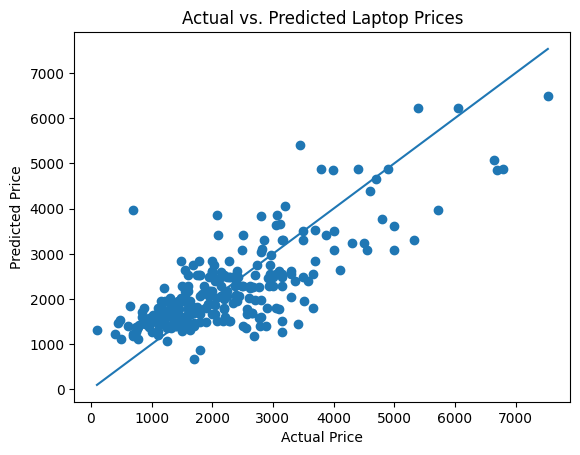

In [18]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Laptop Prices')

plt.show()


## Slice 1 Conclusion

This baseline linear regression used RAM, storage, screen size, CPU brand, and GPU brand to predict laptop price.

The model achieved:

- Training R²: 0.556
- Testing R²: 0.597
- Training MAE: approximately $611
- Testing MAE: approximately $578

The similar training and testing scores suggest that the model is not showing obvious overfitting.

The model explains a meaningful portion of laptop price variation, but its prediction error is still substantial. Broad CPU and GPU brand categories do not capture differences between individual processor and graphics card performance tiers.

RAM, screen size, and NVIDIA GPU presence showed positive relationships with predicted price, while storage alone did not show the expected positive relationship after the other features were considered.

The actual versus predicted plot shows that the model performs reasonably well for many laptops in the common price range, but prediction errors become larger for some higher priced systems.

Overall, this model serves as a useful baseline rather than a final pricing model. More detailed CPU and GPU information may improve prediction accuracy in later stages of the project.